In [71]:
print("check 1")

import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import leafmap
import rasterio
from rasterio.warp import reproject, Resampling
import inspect

#del gdf_tree_circles
import importlib
import Constants
importlib.reload(Constants)
import Utils
#importlib.reload(Utils)
print("check 1")
import ConstantObjects
importlib.reload(ConstantObjects)
%whos
#autoreload all modules in every cell. Remove 
%load_ext autoreload
%autoreload 2


print("check 2")

# Use the TiTiler demo endpoint. Replace this if needed.
os.environ["TITILER_ENDPOINT"] = "https://giswqs-titiler-endpoint.hf.space"
Map = leafmap.Map()
Map

print("check 3")


B08_band_filename = Utils.download_band_dynamic("2025-05-02", "B08", Constants.lat0, Constants.lon0, cache_dir="s2_point_series")
print("check 4")

B11_band_filename = Utils.download_band_dynamic("2025-05-02", "B11", Constants.lat0, Constants.lon0, cache_dir="s2_point_series")
        
print(f"[Line {inspect.currentframe().f_lineno}] ... B08_band_filename: ",B08_band_filename)



check 1
check 1
[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783454.50783975 2246774.099946275
-10783545.138618454 2246731.83812010

B08 shape: (10980, 10980)
B11 shape before resampling: (5490, 5490)
B11 shape after resampling: (10980, 10980)
about to display matplotlib ndmi image


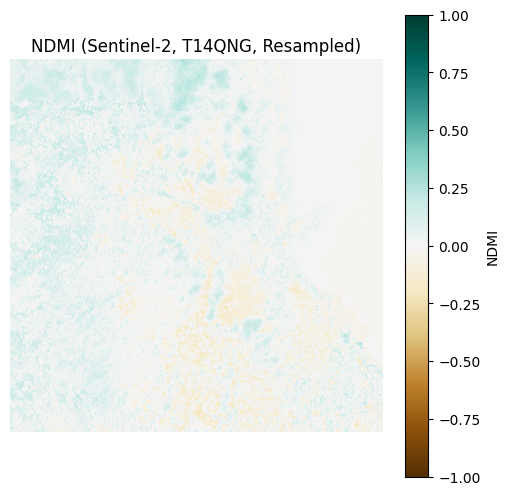

done with display matplotlib ndmi image
✅ NDMI GeoTIFF saved to: ndmi_fixed.tif


Map(center=[19.7782, -96.86942], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

In [72]:




# Read B08 (10m NIR)
with rasterio.open(B08_band_filename) as src_nir:
    B08 = src_nir.read(1).astype("float32")
    nir_profile = src_nir.profile
    print("B08 shape:", B08.shape)
    B08_transform = src_nir.transform
    B08_crs = src_nir.crs

# Read B11 (20m SWIR)
with rasterio.open(B11_band_filename) as src_swir:
    B11_orig = src_swir.read(1).astype("float32")
    swir_profile = src_swir.profile
    print("B11 shape before resampling:", B11_orig.shape)
    B11_transform = src_swir.transform
    B11_crs = src_swir.crs



# Prepare empty array to match B08 shape
B11_resampled = np.empty_like(B08, dtype="float32")

# Reproject (resample) B11 to B08's shape/resolution
reproject(
    source=B11_orig,
    destination=B11_resampled,
    src_transform=B11_transform,
    src_crs=B11_crs,
    dst_transform=B08_transform ,
    dst_crs=B08_crs,
    resampling=Resampling.bilinear
)

print("B11 shape after resampling:", B11_resampled.shape)




# Compute NDMI
myNdmiMax = .1
myNdmiMin = -.1
ndmi = np.where((B08 + B11_resampled) == 0, 0, 0) # initialize
ndmi = np.where((B08 + B11_resampled) == 0, 0, (B08 - B11_resampled) / (B08 + B11_resampled))

# Plot NDMI
plt.figure(figsize=(6, 6))
plt.imshow(ndmi, cmap='BrBG', vmin=-1, vmax=1) #should display out a 2D image file
plt.colorbar(label="NDMI")
plt.title("NDMI (Sentinel-2, T14QNG, Resampled)")
plt.axis('off')
print("about to display matplotlib ndmi image")
plt.show()
print("done with display matplotlib ndmi image")





"""
# Flip vertically to match imshow orientation (optional, but usually needed)
ndmi_flipped = np.flipud(ndmi)
# Set up the figure
plt.figure(figsize=(6, 6))
# Plot contour lines only (black)
contours = plt.contour(ndmi_flipped, levels=np.linspace(-1, 1, 4), colors='black', linewidths=0.7)
# Optionally label the contour lines
plt.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
# Title and formatting
plt.title("NDMI Isolines (Sentinel-2, T14QNG, Resampled)")
plt.axis('off')
print("about to display matplotlib NDMI contour image")
plt.show()
print("done with display matplotlib NDMI contour image")
"""




# Bounding box for tile T14QNG in lat/lon (WGS84)
bounds_wgs84 = (-96.98, 19.53, -96.38, 20.03)
tile_width, tile_height = 10980, 10980  # 10m resolution
from rasterio.transform import from_bounds

transform_override = from_bounds(*bounds_wgs84, tile_width, tile_height)
crs_override = "EPSG:4326"




output_tif = "ndmi_fixed.tif"

# Save to GeoTIFF
with rasterio.open(
    output_tif,
    "w",
    driver="GTiff",
    height=ndmi.shape[0],
    width=ndmi.shape[1],
    count=1,
    dtype="float32",
    crs=crs_override,
    transform=transform_override,
) as dst:
    dst.write(ndmi, 1)

    

print("✅ NDMI GeoTIFF saved to:", output_tif)



Map = leafmap.Map()
Map.add_basemap("HYBRID")  # Google satellite imagery
Map.add_raster(output_tif, layer_name="NDMI", opacity=0.7)
Map.add_raster("ndmi.tif", layer_name="NDMI", opacity=0.7)






Map.add_tile_layer(
    url="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    name="OpenStreetMap Overlay",
    attribution="© OpenStreetMap contributors",
    opacity=0.4
)

Map.set_center(lon= Constants.lon0, lat= Constants.lat0, zoom=18)  # Veracruz

Map


In [73]:

# Visualize with leafmap
importlib.reload(ConstantObjects)
import ipywidgets as widgets
from ipyleaflet import Marker



Map = leafmap.Map()
Map.add_basemap("HYBRID")
Map.add_gdf(ConstantObjects.gdf_plotMilpa1, layer_name="Plot Boundary", style={"color": "yellow", "fillOpacity": 0.})
Map.add_gdf(ConstantObjects.gdf_plotMilpa2, layer_name="Plot Boundary", style={"color": "yellow", "fillOpacity": 0.})
Map.add_gdf(ConstantObjects.gdf_box_terreno_casa, layer_name="Plot Boundary", style={"color": "yellow", "fillOpacity": 0.})
Map.add_gdf(ConstantObjects.gdf_box_pueblo, layer_name="Pueblo", style={"color": "yellow", "fillOpacity": 0.})
Map.add_gdf(ConstantObjects.gdf_plot14QKH, layer_name="14QKH tile", style={"color": "yellow", "fillOpacity": 0.})
Map.add_gdf(ConstantObjects.gdf_plot14QKG, layer_name="14QKG tile", style={"color": "yellow", "fillOpacity": 0.})

# Create the popup widget
popup_text = widgets.HTML(value=f"<b>Lat:</b> {Constants.lat0}<br><b>Lon:</b> {Constants.lon0}")

# Create the marker with popup
marker = Marker(location=(Constants.lat0, Constants.lon0), popup=popup_text)
Map.add_layer(marker)

#Map.add_marker(location=[Constants.lat0, Constants.lon0], popup=f"Lat: {lat}, Lon: {lon}")


# Optionally overlay NDMI
#if os.path.exists(output_tif):
#    Map.add_raster(output_tif, layer_name="NDMI", opacity=0.7)

# Center on the plot
Map.set_center(-96.8706, 19.7771, zoom=18)
Map



[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783454.50783975 2246774.099946275
-10783545.138618454 2246731.838120101
-10783516.4005

Map(center=[19.7771, -96.8706], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…

In [57]:
from shapely.geometry import Polygon
import geopandas as gpd
import math






[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783454.50783975 2246774.099946275
-10783545.138618454 2246731.838120101
-10783516.4005

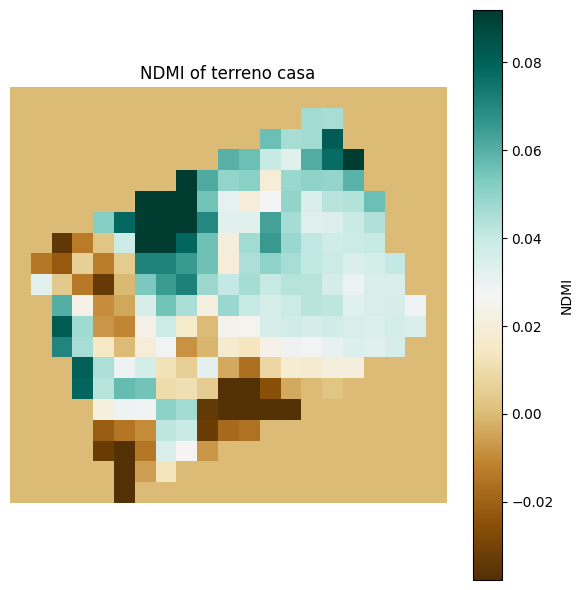

Saving with CRS: EPSG:4326
[Line 47] n_cols: 21, n_rows: 18
[Line 48] n_cols in ConstantObjects: 21
check 20


Map(center=[19.7782, -96.86942], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

In [75]:
#import Utils
importlib.reload(Utils)
importlib.reload(Constants)
importlib.reload(ConstantObjects)
import inspect





#n_cols=100
"""
n_rows=10
dx=5
dy=4
rotation_deg=0
"""



from rasterio.mask import mask



print ("check 10.1")

ndmi_save_path = "ndmi_terreno_casa.tif"

#ndmi_crop, out_transform, out_meta = crop_and_plot_ndmi(ndmi_path, plot_gdf, title="NDMI Cropped", show_plot=True, save_path=None):
gdf_box_surroundings = Utils.draw_grid_box(
    Constants.lat0,
    Constants.lon0,
    Constants.dx,Constants.dy,
    Constants.n_cols,Constants.n_rows,
    Constants.rotation_deg,
    col1=0, row1=0,
    col2= 100, row2=100
)

#ndmi_crop, out_transform, out_meta = Utils.crop_and_plot_ndmi(output_tif, gdf_box_surroundings, title="NDMI of surroundings", show_plot=True, save_path= ndmi_save_path)
ndmi_crop, out_transform, out_meta = Utils.crop_and_plot_ndmi(output_tif, ConstantObjects.gdf_box_terreno_casa, title="NDMI of terreno casa", show_plot=True, save_path= ndmi_save_path)


Map = leafmap.Map(overwrite=True)
Map.add_basemap("Esri.WorldImagery")

print(f"[Line {inspect.currentframe().f_lineno}] n_cols: {Constants.n_cols}, n_rows: {Constants.n_rows}")
print(f"[Line {inspect.currentframe().f_lineno}] n_cols in ConstantObjects: {Constants.n_cols}")
print ("check 20")
#Map.add_gdf(gdf_tree_circles, layer_name="Tree Circles", style={"color": "cyan", "fillColor": "green", "fillOpacity": 0.6})
Map.add_gdf(ConstantObjects.gdf_tree_circles, layer_name="Tree Circles", style={"color": "cyan", "fillColor": "green", "fillOpacity": 0.6})
#Map.add_gdf(gdf_tree_circles_notebook, layer_name="Tree Circles", style={"color": "red", "fillColor": "green", "fillOpacity": 0.6})
Map.add_gdf(ConstantObjects.gdf_box_terreno_casa, layer_name="Grid Box", style={"color": "orange", "fillOpacity": 0})
Map.add_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B, layer_name="Grid Box", style={"color": "orange", "fillOpacity": 0})
Map.add_gdf(ConstantObjects.gdf_box_pueblo, layer_name="Grid Box", style={"color": "orange", "fillOpacity": 0})
Map.add_gdf(gdf_box_surroundings,layer_name="Grid Box", style={"color": "orange", "fillOpacity": 0})

Map.set_center(Constants.lon0, Constants.lat0, zoom=18)
Map

In [76]:

            
from rasterstats import zonal_stats

stats_plots_4_5 = zonal_stats(
    ConstantObjects.gdf_box_plots_4_5,
    output_tif,
    stats=["mean", "median"],
    nodata=None
)

print("plots 4,5 :",stats_plots_4_5)

stats_plots_2_3_1A_1B = zonal_stats(
    ConstantObjects.gdf_box_plots_2_3_1A_1B,
    output_tif,
    stats=["mean", "median"],
    nodata=None
)

print("plots 1A,1B,2,3 : ",stats_plots_2_3_1A_1B)

#was  : [{'mean': -0.026324648748744617, 'median': -0.024272000417113304}] # dry patch is dryer in this position
#[{'mean': -0.037154800551278254, 'median': -0.0263974666595459}]
#shifted -2 columns:
#[{'mean': -0.05803736231543801, 'median': -0.07068529725074768}]
#green :  [{'mean': -0.05952849653032091, 'median': -0.061329811811447144}] # wet patch is wetter in this position

RasterioIOError: 'ndmi_fixed.tif' not recognized as being in a supported file format.

In [60]:
import leafmap

Map = leafmap.Map(center=[19.777411, -96.870102], zoom=12)
Map.add_raster("ndmi_reprojected.tif", layer_name="NDMI", opacity=0.9)
#Map.add_basemap("OpenStreetMap")
Map

Map(center=[19.398815499999998, -98.4757545], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…

In [61]:
# Re-run the previous code after reset

import os
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import transform
import matplotlib.pyplot as plt
import requests
from datetime import datetime
from tempfile import NamedTemporaryFile
#import Utils



# Output lists
ndmi_values = []
valid_dates = []

# Prepare folder
os.makedirs("s2_point_series", exist_ok=True)
#SCF

myDates = Utils.generate_date_range("2025-01-02", "2025-07-26",  "%Y-%m-%d", 5)

# Sample NDMI at the given point
#for date in Constants.dates:
for date in myDates:
    print("processing date ",date)
    b08_path = Utils.download_band_dynamic(date, "B08",Constants.lat0,Constants.lon0)
    b11_path = Utils.download_band_dynamic(date, "B11",Constants.lat0,Constants.lon0)
    print(f"[Line {inspect.currentframe().f_lineno}] ... ")

    if not b08_path or not b11_path:
        print(f"[Line {inspect.currentframe().f_lineno}] ... ")
        continue

    try:
        with rasterio.open(b08_path) as src_b08, rasterio.open(b11_path) as src_b11:
            print(f"[Line {inspect.currentframe().f_lineno}] ... ")

            # Transform point to image coordinates
            point_x, point_y = transform('EPSG:4326', src_b08.crs, [lon], [lat])
            row, col = src_b08.index(point_x[0], point_y[0])
            print(f"[Line {inspect.currentframe().f_lineno}] ... row, col = ",row,col)
            b08 = src_b08.read(1)[row, col].astype(float)
            print(f"[Line {inspect.currentframe().f_lineno}] ... ")
            b11 = src_b11.read(1)[row, col].astype(float)
            print(f"[Line {inspect.currentframe().f_lineno}] ... ")

            if (b08 + b11) != 0:
                print(f"[Line {inspect.currentframe().f_lineno}] ... ")
                ndmi = (b08 - b11) / (b08 + b11)
                ndmi_values.append(ndmi)
                valid_dates.append(datetime.strptime(date, "%Y-%m-%d"))
                print(f"[Line {inspect.currentframe().f_lineno}] ... ")
    except Exception as e:
        print(f"[Line {inspect.currentframe().f_lineno}] ... ")
        print(f"Skipping {date} due to error: {e}")

print(f"[Line {inspect.currentframe().f_lineno}] ... ")


# Plot NDMI vs Time
if valid_dates and ndmi_values:
    plt.figure(figsize=(10, 5))
    plt.plot(valid_dates, ndmi_values, marker='o', linestyle='-')
    plt.xlabel("Date")
    plt.ylabel("NDMI")
    plt.title("NDMI Time Series at Point (AWS Sentinel-2)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No NDMI values extracted. Try different dates or location.")



processing date  2025-01-02
[Line 92] ... lat       =  19.7782
[Line 93] ... lon       =  -96.86942
[Line 94] ... mgrs_tile =  14QQG
tile id:  14QQG
base_url =  https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/QG/2025/1/2/0/B08.jp2
[Line 132] ... Using cached file:  s2_point_series/14QQG_2025-01-02_B08.jp2
[Line 92] ... lat       =  19.7782
[Line 93] ... lon       =  -96.86942
[Line 94] ... mgrs_tile =  14QQG
tile id:  14QQG
base_url =  https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/QG/2025/1/2/0/B11.jp2
[Line 132] ... Using cached file:  s2_point_series/14QQG_2025-01-02_B11.jp2
[Line 32] ... 
[Line 40] ... 
[Line 58] ... 
Skipping 2025-01-02 due to error: name 'lon' is not defined
processing date  2025-01-07
[Line 92] ... lat       =  19.7782
[Line 93] ... lon       =  -96.86942
[Line 94] ... mgrs_tile =  14QQG
tile id:  14QQG
base_url =  https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/QG/2025/1/7/0/B08.jp2
[Line 132] ... Using cached file:  s2_point_series/14QQG_2025-01-0

check 0
check 1
check 2
check 3
processing date  2025-01-02
[Line 92] ... lat       =  19.7782
[Line 93] ... lon       =  -96.86942
[Line 94] ... mgrs_tile =  14QQG
tile id:  14QQG
base_url =  https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/QG/2025/1/2/0/B08.jp2
[Line 132] ... Using cached file:  s2_point_series/14QQG_2025-01-02_B08.jp2
[Line 92] ... lat       =  19.7782
[Line 93] ... lon       =  -96.86942
[Line 94] ... mgrs_tile =  14QQG
tile id:  14QQG
base_url =  https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/QG/2025/1/2/0/B11.jp2
[Line 132] ... Using cached file:  s2_point_series/14QQG_2025-01-02_B11.jp2
processing date  2025-01-07
[Line 92] ... lat       =  19.7782
[Line 93] ... lon       =  -96.86942
[Line 94] ... mgrs_tile =  14QQG
tile id:  14QQG
base_url =  https://sentinel-s2-l1c.s3.amazonaws.com/tiles/14/Q/QG/2025/1/7/0/B08.jp2
[Line 132] ... Using cached file:  s2_point_series/14QQG_2025-01-07_B08.jp2
[Line 92] ... lat       =  19.7782
[Line 93] ... lon       =  -

ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed


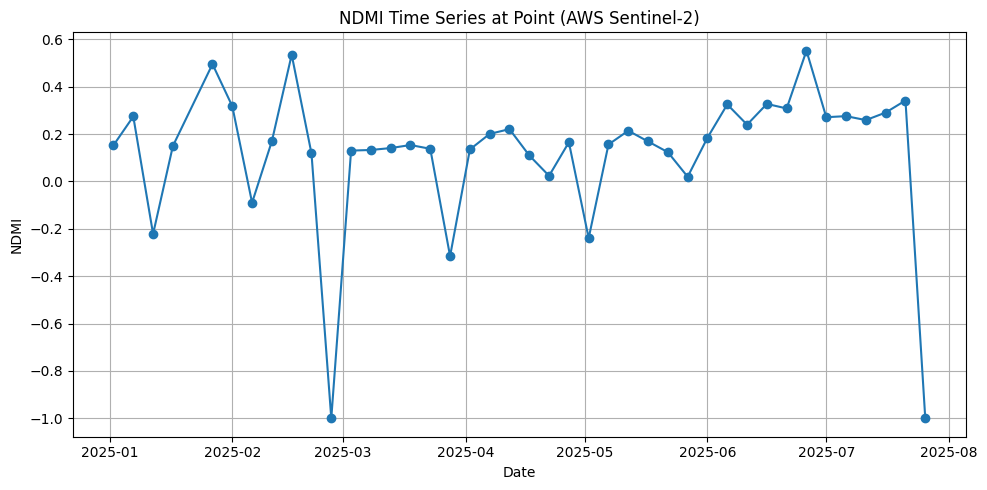

In [63]:
# Re-run the previous code after reset
print ("check 0")

"""import os
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import transform
import matplotlib.pyplot as plt
import requests
from datetime import datetime
from tempfile import NamedTemporaryFile
from rasterio.coords import BoundingBox
"""
print ("check 1")
# Point of interest (Veracruz)
#lat, lon = 19.777411, -96.870102

# Sentinel-2 tile metadata
tile = {
    "utm_zone": "14",
    "latitude_band": "Q",
    "grid_square": "NG"
}

# Dates you want to sample NDMI from (you can extend this list)
dates = [
    "2025-05-02",
    "2025-05-04",
    "2025-05-05",
    "2025-05-07",
    "2025-05-10",
    "2025-05-12"
]

# Output lists
ndmi_values = []
valid_dates = []

# Prepare folder
os.makedirs("s2_point_series", exist_ok=True)
print ("check 2")


    #b08_path = Utils.download_band(date, "B08")
    #b11_path = Utils.download_band(date, "B11")

print ("check 3")

#myDates = Utils.generate_date_range("2025-05-02", "2025-07-26",  "%Y-%m-%d", 5)


# Sample NDMI at the given point
#for date in Constants.dates:
for date in myDates:

    print("processing date ",date)
    b08_path = Utils.download_band_dynamic(date, "B08",Constants.lat0,Constants.lon0)
    b11_path = Utils.download_band_dynamic(date, "B11",Constants.lat0,Constants.lon0)
    
    if not b08_path or not b11_path:
        continue

    try:
        with rasterio.open(b08_path) as src_b08, rasterio.open(b11_path) as src_b11:
            # Transform point to image coordinates
            bounds: BoundingBox = src_b08.bounds
            point_x, point_y = transform('EPSG:4326', src_b08.crs, [Constants.lon0], [Constants.lat0])


            if bounds.left <= point_x[0] <= bounds.right and bounds.bottom <= point_y[0] <= bounds.top:
                row, col = src_b08.index(point_x, point_y)
                if 0 <= row < src_b08.height and 0 <= col < src_b08.width:
                    b08 = src_b08.read(1)[row, col].astype(float)
                    b11 = src_b11.read(1)[row, col].astype(float)
            
                else:
                    print(f"Point inside bounds, but pixel index out of image dimensions.")
                    continue # don't run the rest
            else:
                print(f"Point {lon},{lat} outside tile bounds {bounds}, skipping date {date}")
                continue # don't run the rest


            
            row, col = src_b08.index(point_x[0], point_y[0])

            b08 = src_b08.read(1)[row, col].astype(float)
            b11 = src_b11.read(1)[row, col].astype(float)

            if (b08 + b11) != 0:
                ndmi = (b08 - b11) / (b08 + b11)
                ndmi_values.append(ndmi)
                valid_dates.append(datetime.strptime(date, "%Y-%m-%d"))
    except Exception as e:
        print(f"Skipping {date} due to error: {e}")

# Plot NDMI vs Time
if valid_dates and ndmi_values:
    plt.figure(figsize=(10, 5))
    plt.plot(valid_dates, ndmi_values, marker='o', linestyle='-')
    plt.xlabel("Date")
    plt.ylabel("NDMI")
    plt.title("NDMI Time Series at Point (AWS Sentinel-2)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No NDMI values extracted. Try different dates or location.")

